In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import roc_auc_score 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("accepted.csv", low_memory=False)

Target = "int_rate"

keep_columns = {
    "fico_range_low", "term", "bc_util", "revol_util", "inq_last_6mths", 
    "total_rev_hi_lim", "dti", "mths_since_recent_inq", "earliest_cr_line",
    "loan_amnt", "sub_grade", "verification_status", "initial_list_status", 
    "purpose", "home_ownership", "application_type", "int_rate"
}

keep_columns = [c for c in keep_columns if c in df.columns]
df = df[keep_columns].copy()

df[Target] = pd.to_numeric(df[Target], errors="coerce")


In [3]:

date = pd.Timestamp("2018-01-01")
df["credit_history_yrs"] = (
    (date - pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")).dt.days / 365.25
).round(1)
df.drop(columns=["earliest_cr_line"], inplace=True)

df = df[df["dti"] < 100] # removes 999 values

null_cols = df.select_dtypes(include="number").columns.drop(Target, errors="ignore").tolist()
df[null_cols] = df[null_cols].fillna(df[null_cols].median())


In [ ]:

df = pd.get_dummies(df, columns=["sub_grade", "verification_status", "initial_list_status",
                                 "purpose", "home_ownership", "application_type", "term"])

In [5]:
print(df["credit_history_yrs"].isna().mean())

0.0


In [7]:
x = df.drop (columns=[Target])
y = df[Target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=43, n_jobs=-1)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")

R²:   0.9667
MAE:  0.6018
RMSE: 0.8801


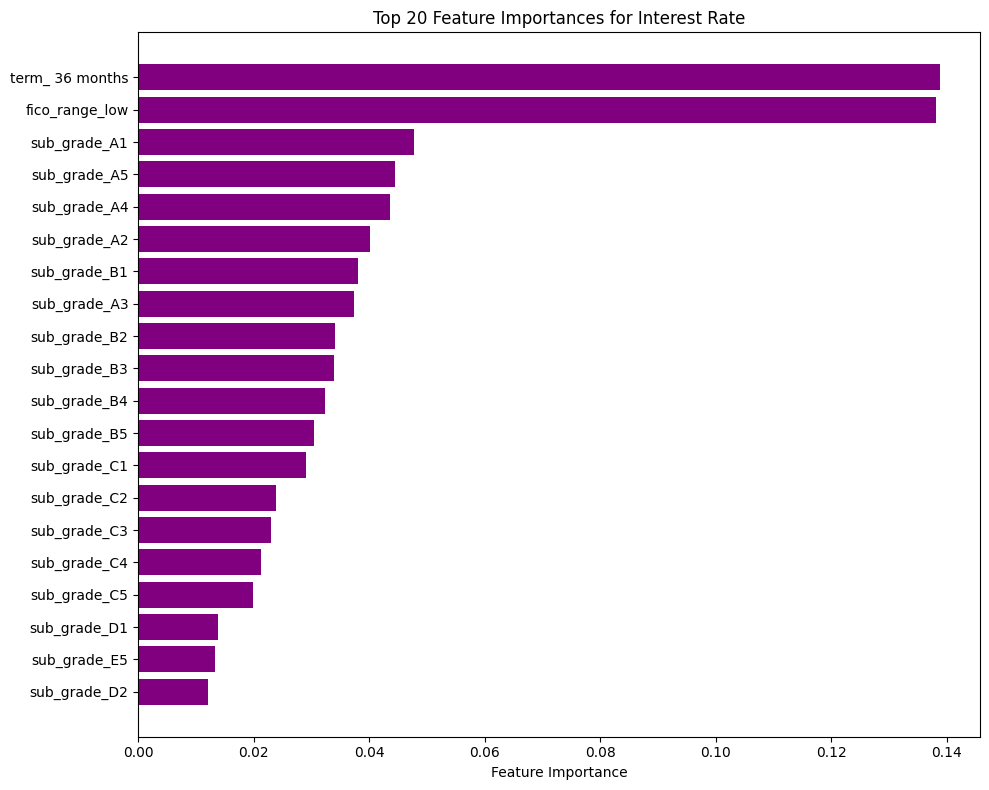

In [34]:
importances = rf.feature_importances_
feature_names = x_train.columns
feat_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_df["feature"][::-1], feat_df["importance"][::-1], color="purple")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Feature Importances for Interest Rate")
plt.tight_layout()
plt.show()
plt.close()


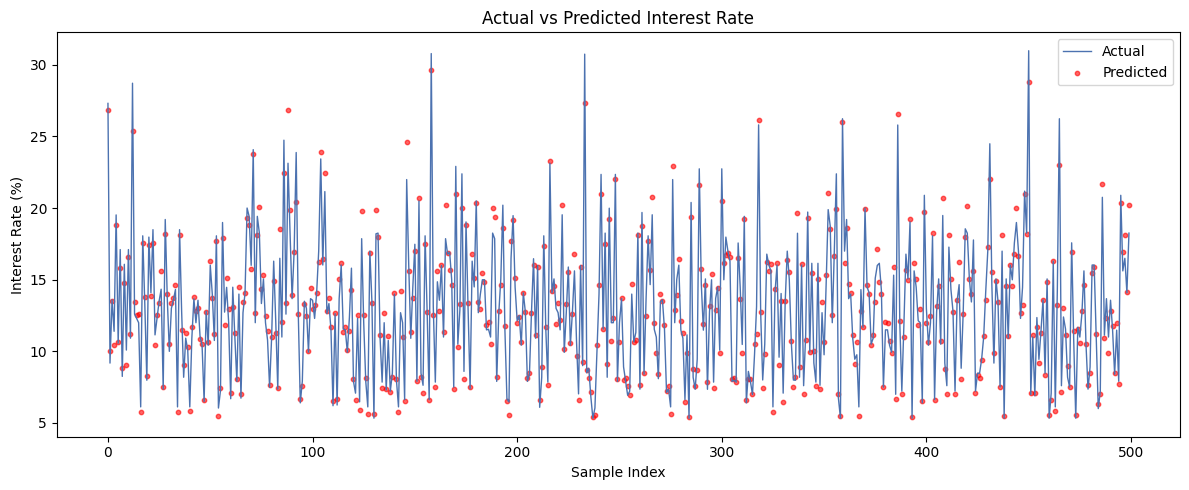

In [35]:
sample_idx = y_test.sample(500, random_state=42).index
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(500), y_test.loc[sample_idx].values, color="#4C72B0", linewidth=1, label="Actual")
ax.scatter(range(500), y_pred[y_test.index.get_indexer(sample_idx)], 
           color="red", s=10, alpha=0.6, label="Predicted")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Interest Rate (%)")
ax.set_title("Actual vs Predicted Interest Rate")
ax.legend()
plt.tight_layout()

plt.show()
plt.close()

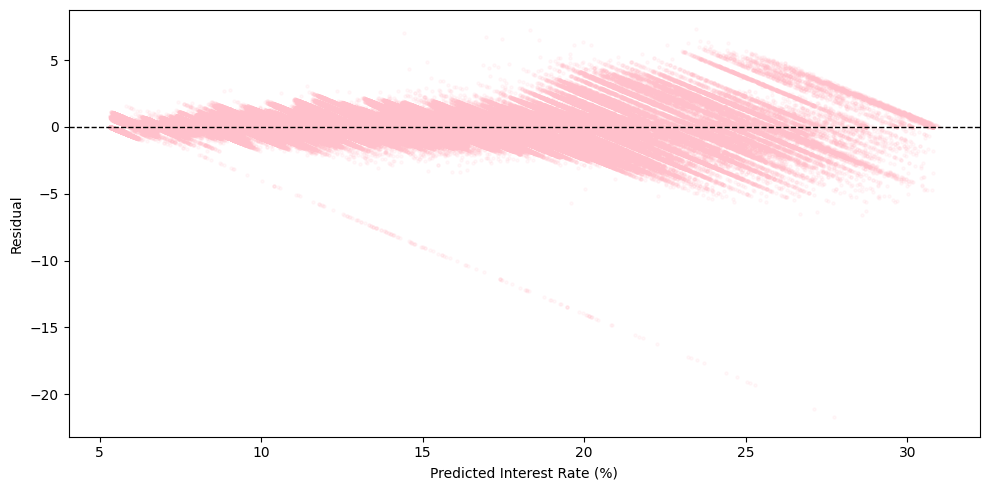

In [17]:
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_pred, residuals, alpha=0.1, s=5, color="pink")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted Interest Rate (%)")
ax.set_ylabel("Residual")
plt.tight_layout()

plt.show()
plt.close()

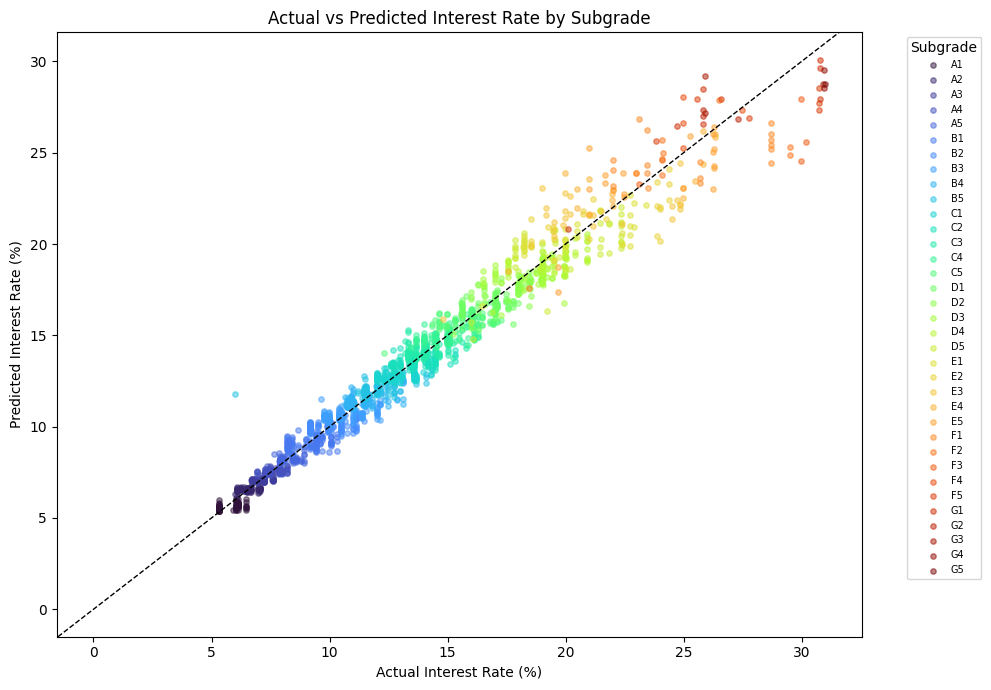

In [36]:
sample_idx = y_test.sample(2000, random_state=42).index
grade_col = x_test.filter(like="sub_grade").idxmax(axis=1).str.replace("sub_grade_", "")

fig, ax = plt.subplots(figsize=(10, 7))
grades = grade_col.loc[sample_idx].unique()
colors = plt.cm.turbo(np.linspace(0, 1, len(sorted(grades))))

for grade, color in zip(sorted(grades), colors):
    mask = grade_col.loc[sample_idx] == grade
    ax.scatter(
        y_test.loc[sample_idx][mask],
        y_pred[y_test.index.get_indexer(sample_idx)][mask],
        color=color, alpha=0.5, s=15, label=grade
    )

ax.axline((0, 0), slope=1, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Actual Interest Rate (%)")
ax.set_ylabel("Predicted Interest Rate (%)")
ax.set_title("Actual vs Predicted Interest Rate by Subgrade")
ax.legend(title="Subgrade", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()
plt.close()

In [37]:
df.to_csv("cleaned_int_rate.csv", index=False)